# Риски. Байесовские и минимаксные оценки


**Исполнитель (ФИО):** Липунцов Антон Юрьевич
---

Здравствуйте! В этом практикуме вам предстоит познакомиться с численным рассчётом рисков байесовских и минимаксных оценок

Вы уже научились строить некоторые виды "хороших" оценок по определенным правилам, в том числе и такие оценки $\hat{\theta}$, которые приближают истинное значение параметра $\theta$.

На практике часто оказывается, что мы не можем построить оценку, которая сколь угодно точно оценивает параметр распределения, однако, мы можем определить для себя приемлемый диапазон того, насколько мы можем ошибиться при оценке параметра $\theta$.

Потери мы можем оценивать с помощью соответствующих функций, идея которых в том, чтобы посчитать "разность" между параметром и его оценкой:
1. $L(\theta,\hat{\theta})=(\theta-\hat{\theta})^{2}$ - квадратичная функция потерь
2. $L(\theta,\hat{\theta})=|\theta-\hat{\theta}|$ - абсолютная функция потерь
3. $L(\theta,\hat{\theta})=I_{\theta\neq\hat{\theta}}$ - дискретная функция потерь
4. $L(\theta,\hat{\theta})=\bigg(\dfrac{\theta-\hat{\theta}}{\theta}\bigg)^{2}$ - относительная квадратичная функция потерь
5. $L(\theta,\hat{\theta})=\bigg|\dfrac{\theta-\hat{\theta}}{\theta}\bigg|$ - относительная абсолютная функция потерь

Разумеется, любую функцию $L(\theta,\hat{\theta})$ такую, что
1. $L(\theta,\hat{\theta}) > 0$
2. $L(\theta,\hat{\theta}) = 0 \iff \theta=\hat{\theta}$

можно рассматривать как функцию потерь

## Задача 1

Конкретное значение функции потерь зависит от реализации выборки, а значит и оценки $\hat{\theta}$, поэтому мы бы хотели смотреть на то, насколько мы ошибаемся в среднем, когда используем оценку $\hat{\theta}$. Такую величину называют риском $R(\theta,\hat{\theta})=\mathbb{E}_{\theta}\big[L\big(\theta,\hat{\theta}(X_{1},\ldots,X_{n})\big)\big]$

Сгенерируйте выборку $X_{1},\ldots,X_{n}\sim \mathcal{N}\big(0, \frac{1}{\theta}\big)$

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gamma, beta, norm, uniform, poisson
from scipy.special import gammaln
import seaborn as sns

In [4]:
def sample_normal(theta, n):
    sigma = 1 / np.sqrt(theta)
    return np.random.normal(0, sigma, n)

Посчитайте квадратичный и абсолютный риски для следующих оценок параметра $\theta$:
1. Несмещенная дисперсия
2. ОМС
3. Байесовская оценка для квадратичной функции потерь: $\dfrac{n+2\alpha}{\sum X_{i}^{2} + 2\beta}$ - для априорного распределения $Gamma(\alpha,\beta)$
4. Байесовская оценка для абсолютной функции потерь: медиана случайной величины $Z\sim Gamma\bigg(\dfrac{n}{2}+\alpha,\dfrac{\sum X_{i}^{2}}{2}+\beta\bigg)$ - для априорного распределения $Gamma(\alpha,\beta)$

Попробуйте разные значения параметров $\alpha,\beta>0$

In [8]:
def theta_unsv(X):
    n = len(X)
    return (n-1) / np.sum(X**2)

def theta_ml(X):
    n = len(X)
    return n / np.sum(X**2)

def theta_bayes_sq(X, alpha, beta):
    n = len(X)
    return (n + 2*alpha) / (np.sum(X**2) + 2*beta)

def theta_bayes_abs(X, alpha, beta):
    n = len(X)
    shape = n/2 + alpha
    scale = 1 / (np.sum(X**2)/2 + beta)
    return gamma.median(shape, scale=scale)

N_SIM = 5000

def compute_risks(theta_true, n, alpha, beta, n_sim=N_SIM):
    sq_loss_unsv, abs_loss_unsv = [], []
    sq_loss_ml, abs_loss_ml = [], []
    sq_loss_bayes, abs_loss_bayes = [], []
    sq_loss_bayes_abs, abs_loss_bayes_abs = [], []

    for _ in range(n_sim):
        X = sample_normal(theta_true, n)

        t_unsv = theta_unsv(X)
        t_ml = theta_ml(X)
        t_bay_sq = theta_bayes_sq(X, alpha, beta)
        t_bay_abs = theta_bayes_abs(X, alpha, beta)

        sq_loss_unsv.append((theta_true - t_unsv)**2)
        abs_loss_unsv.append(np.abs(theta_true - t_unsv))

        sq_loss_ml.append((theta_true - t_ml)**2)
        abs_loss_ml.append(np.abs(theta_true - t_ml))

        sq_loss_bayes.append((theta_true - t_bay_sq)**2)
        abs_loss_bayes.append(np.abs(theta_true - t_bay_sq))

        sq_loss_bayes_abs.append((theta_true - t_bay_abs)**2)
        abs_loss_bayes_abs.append(np.abs(theta_true - t_bay_abs))

    return {
        'unsv': (np.mean(sq_loss_unsv), np.mean(abs_loss_unsv)),
        'ml': (np.mean(sq_loss_ml), np.mean(abs_loss_ml)),
        'bayes_sq': (np.mean(sq_loss_bayes), np.mean(abs_loss_bayes)),
        'bayes_abs': (np.mean(sq_loss_bayes_abs), np.mean(abs_loss_bayes_abs))
    }

def mean_estimates(theta_vals, n, alpha, beta, n_sim=2000):
    res = {'theta': theta_vals, 'unsv': [], 'ml': [], 'bayes_sq': [], 'bayes_abs': []}
    for th in theta_vals:
        est_unsv, est_ml, est_bsq, est_babs = [], [], [], []
        for _ in range(n_sim):
            X = sample_normal(th, n)
            est_unsv.append(theta_unsv(X))
            est_ml.append(theta_ml(X))
            est_bsq.append(theta_bayes_sq(X, alpha, beta))
            est_babs.append(theta_bayes_abs(X, alpha, beta))
        res['unsv'].append(np.mean(est_unsv))
        res['ml'].append(np.mean(est_ml))
        res['bayes_sq'].append(np.mean(est_bsq))
        res['bayes_abs'].append(np.mean(est_babs))
    return pd.DataFrame(res)

Постройте графики зависимости оценки параметра $\hat{\theta}$ от значения параметра $\theta$

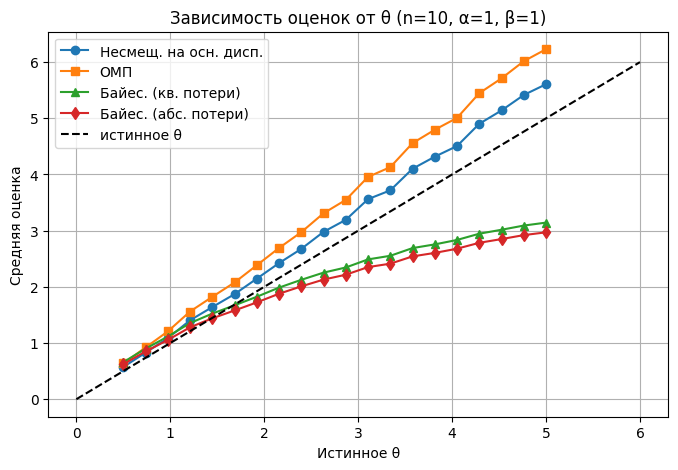

In [9]:
n_sample = 10
alpha0, beta0 = 1, 1
theta_range = np.linspace(0.5, 5, 20)

df_means = mean_estimates(theta_range, n_sample, alpha0, beta0, n_sim=2000)

plt.figure(figsize=(8,5))
plt.plot(df_means['theta'], df_means['unsv'], 'o-', label='Несмещ. на осн. дисп.')
plt.plot(df_means['theta'], df_means['ml'], 's-', label='ОМП')
plt.plot(df_means['theta'], df_means['bayes_sq'], '^-', label='Байес. (кв. потери)')
plt.plot(df_means['theta'], df_means['bayes_abs'], 'd-', label='Байес. (абс. потери)')
plt.plot([0,6], [0,6], 'k--', label='истинное θ')
plt.xlabel('Истинное θ')
plt.ylabel('Средняя оценка')
plt.title(f'Зависимость оценок от θ (n={n_sample}, α={alpha0}, β={beta0})')
plt.legend()
plt.grid(True)
plt.show()

**Вопрос:** Как меняется поведение оценок в зависимости от истинного значения параметра? Как влияет на график размер выборки? Как меняются оценки 3,4 в зависимости от $\alpha,\beta$?

При малых θ разброс оценок больше (дисперсия выборки 1/θ велика).n больше - значит все оценки сходятся к истинному θ, риски уменьшаются. Увеличение α,β приводит к приближению оценки к среднему α/β.

Постройте графики зависимости рисков от значения параметра $\theta$ для вышеописанных оценок

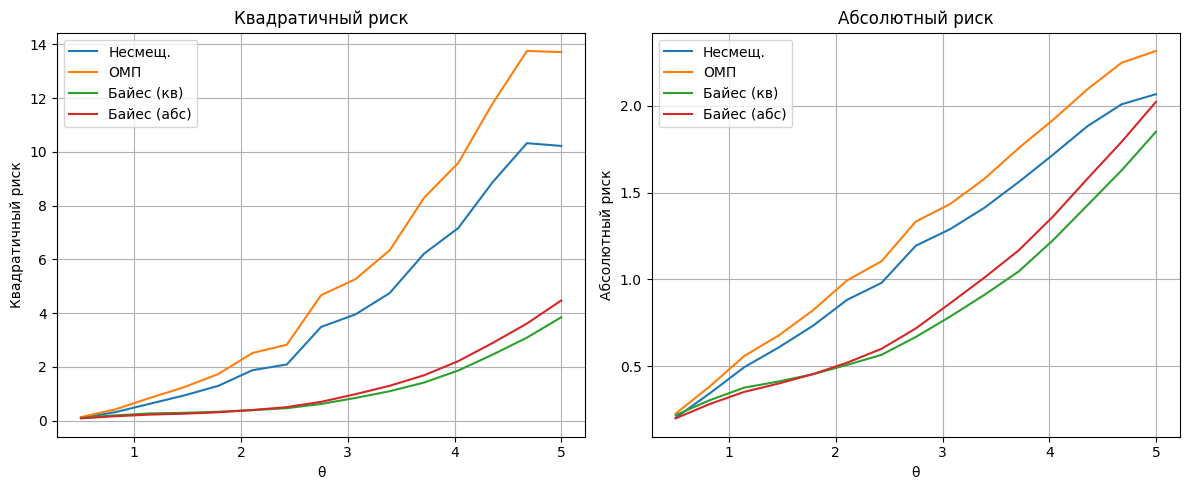

In [10]:
def collect_risks(theta_vals, n, alpha, beta):
    sq_unsv, abs_unsv = [], []
    sq_ml, abs_ml = [], []
    sq_bsq, abs_bsq = [], []
    sq_babs, abs_babs = [], []
    for th in theta_vals:
        r = compute_risks(th, n, alpha, beta, n_sim=2000)
        sq_unsv.append(r['unsv'][0]); abs_unsv.append(r['unsv'][1])
        sq_ml.append(r['ml'][0]); abs_ml.append(r['ml'][1])
        sq_bsq.append(r['bayes_sq'][0]); abs_bsq.append(r['bayes_sq'][1])
        sq_babs.append(r['bayes_abs'][0]); abs_babs.append(r['bayes_abs'][1])
    return {'theta': theta_vals,
            'sq_unsv': sq_unsv, 'abs_unsv': abs_unsv,
            'sq_ml': sq_ml, 'abs_ml': abs_ml,
            'sq_bayes_sq': sq_bsq, 'abs_bayes_sq': abs_bsq,
            'sq_bayes_abs': sq_babs, 'abs_bayes_abs': abs_babs}

theta_range = np.linspace(0.5, 5, 15)
risks = collect_risks(theta_range, n_sample, alpha0, beta0)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(risks['theta'], risks['sq_unsv'], label='Несмещ.')
plt.plot(risks['theta'], risks['sq_ml'], label='ОМП')
plt.plot(risks['theta'], risks['sq_bayes_sq'], label='Байес (кв)')
plt.plot(risks['theta'], risks['sq_bayes_abs'], label='Байес (абс)')
plt.xlabel('θ')
plt.ylabel('Квадратичный риск')
plt.title('Квадратичный риск')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(risks['theta'], risks['abs_unsv'], label='Несмещ.')
plt.plot(risks['theta'], risks['abs_ml'], label='ОМП')
plt.plot(risks['theta'], risks['abs_bayes_sq'], label='Байес (кв)')
plt.plot(risks['theta'], risks['abs_bayes_abs'], label='Байес (абс)')
plt.xlabel('θ')
plt.ylabel('Абсолютный риск')
plt.title('Абсолютный риск')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

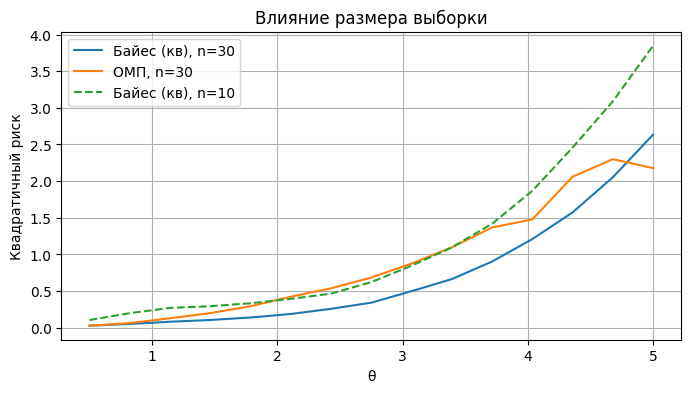

In [11]:
n_large = 30
alpha1, beta1 = 2, 2
risks_large = collect_risks(theta_range, n_large, alpha1, beta1)

plt.figure(figsize=(8,4))
plt.plot(risks_large['theta'], risks_large['sq_bayes_sq'], label=f'Байес (кв), n={n_large}')
plt.plot(risks_large['theta'], risks_large['sq_ml'], label=f'ОМП, n={n_large}')
plt.plot(risks['theta'], risks['sq_bayes_sq'], '--', label=f'Байес (кв), n={n_sample}')
plt.xlabel('θ')
plt.ylabel('Квадратичный риск')
plt.title('Влияние размера выборки')
plt.legend()
plt.grid(True)
plt.show()

**Вопрос:** Какие из оценок дают наименьшие риски? Как влияет на риски размер выборки? Как менются риски некоторых оценок от параметров $\alpha,\beta$?

Байесовские оценки дают меньший риск, чем ОМП или несмещённая, особенно при малых n. При больших n все риски близки.

## Задача 2

Существует несколько подходов к тому, как построить оценку, минимизирующую риск. Байесовский подход один из таких. Пусть из окружающей реальности мы знаем априорное (до выпадения выборки, до опыта) распределение параметра $\theta\sim \pi_{\theta}(t)$ на $\Theta$. Тогда Байесовской оценкой будем называть такую, которая минимизирует Байесовский риск: $R(\hat{\theta})=\int\limits_{\Theta}R(t, \hat{\theta})\pi_{\theta}(t)dt$

На деле, конечно, мы бы ещё и хотели дополнительно подправить априорное распределение нашего параметра с учетом того, какая выборка выпала, то есть получить апостериорное (после опыта) распределение $\pi_{\theta|\vec{X}}(t)=\pi_{\theta}(t)\cdot L_{\theta|\vec{X}}(t)$, то есть подправляем априорную плотность, домножая на функцию правдоподобия. В случае непрерывного распределения последнее есть произведение плотностей, а в дискретном случае - вероятностей

Апостериорное распределение позволяет получить байесовскую оценку, но для каждого риска она своя:
1. Матожидание апостериорного распределения есть байесовская оценка для квадратичного риска, то есть $\theta_{R^{2}}^{B}=\mathbb{E}[Z]$, где $Z\sim\pi_{\theta|\vec{X}}(t)$
2. Медиана апостериорного распределения есть байесовская оценка для абсолютного риска, то есть $\theta_{|R|}^{B}=Median[Z]$, где $Z\sim\pi_{\theta|\vec{X}}(t)$

Пусть $X_{1},\ldots,X_{n}\sim R[0,\theta], \theta\sim \pi_{\theta}(t)=a/t^{a+1},t>1$. Постройте графики априорной и апостериорных плотностей и функций распределения при разных $n$

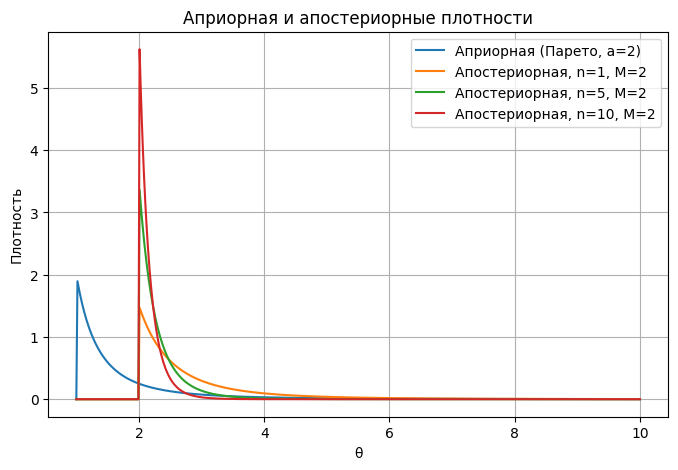

In [13]:
def prior_pareto(t, a):
    return a / t**(a+1) if t > 1 else 0

def posterior_pareto(t, a, M, n):
    shape = a + n
    scale = M
    return shape * (scale**shape) / (t**(shape+1)) if t >= M else 0

a_par = 2
n_vals = [1, 5, 10]
M = 2

t_grid = np.linspace(1, 10, 500)
prior_vals = [prior_pareto(t, a_par) for t in t_grid]

plt.figure(figsize=(8,5))
plt.plot(t_grid, prior_vals, label='Априорная (Парето, a=2)')
for n in n_vals:
    post_vals = [posterior_pareto(t, a_par, M, n) for t in t_grid]
    plt.plot(t_grid, post_vals, label=f'Апостериорная, n={n}, M={M}')
plt.xlabel('θ')
plt.ylabel('Плотность')
plt.title('Априорная и апостериорные плотности')
plt.legend()
plt.grid(True)
plt.show()

Постройте байесовские оценки для квадратичного и абсолютного рисков. Сравните их, построив графики зависимости оценки от истинного значения параметра

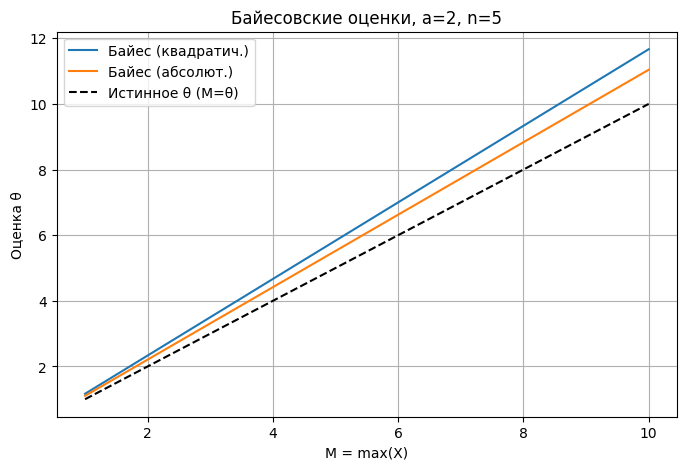

In [14]:
def bayes_pareto_sq(M, a, n):
    shape = a + n
    return M * shape / (shape - 1) if shape > 1 else np.inf

def bayes_pareto_abs(M, a, n):
    shape = a + n
    return M * 2**(1/shape)

M_vals = np.linspace(1, 10, 50)
a_par = 2
n_fixed = 5
estimates_sq = [bayes_pareto_sq(M, a_par, n_fixed) for M in M_vals]
estimates_abs = [bayes_pareto_abs(M, a_par, n_fixed) for M in M_vals]

plt.figure(figsize=(8,5))
plt.plot(M_vals, estimates_sq, label='Байес (квадратич.)')
plt.plot(M_vals, estimates_abs, label='Байес (абсолют.)')
plt.plot(M_vals, M_vals, 'k--', label='Истинное θ (M=θ)')
plt.xlabel('M = max(X)')
plt.ylabel('Оценка θ')
plt.title(f'Байесовские оценки, a={a_par}, n={n_fixed}')
plt.legend()
plt.grid(True)
plt.show()

Cравните, какая из байесовских оценок чаще оказывается ближе к $\theta$ при разных $n$, cмоделировав для этого по $M > 1000$ реализаций для каждого $n$

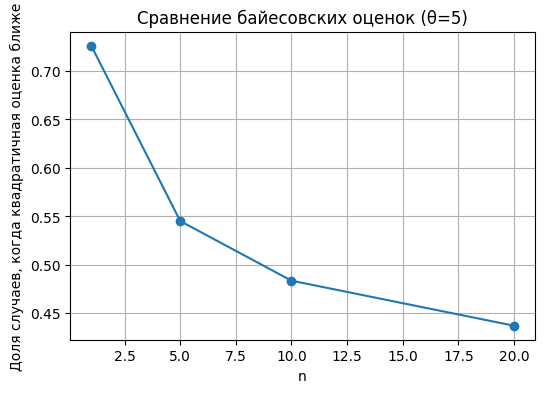

Доля побед квадратичной оценки: [0.726, 0.545, 0.4835, 0.437]


In [15]:
def compare_bayes_pareto(theta_true, a, n, n_sim=1000):
    closer_sq = 0
    for _ in range(n_sim):
        X = np.random.uniform(0, theta_true, n)
        M = np.max(X)
        est_sq = bayes_pareto_sq(M, a, n)
        est_abs = bayes_pareto_abs(M, a, n)
        if abs(est_sq - theta_true) < abs(est_abs - theta_true):
            closer_sq += 1
    return closer_sq / n_sim

theta_true_fixed = 5
n_vals = [1, 5, 10, 20]
ratios = []
for n in n_vals:
    rat = compare_bayes_pareto(theta_true_fixed, a_par, n, n_sim=2000)
    ratios.append(rat)

plt.figure(figsize=(6,4))
plt.plot(n_vals, ratios, 'o-')
plt.xlabel('n')
plt.ylabel('Доля случаев, когда квадратичная оценка ближе')
plt.title('Сравнение байесовских оценок (θ=5)')
plt.grid(True)
plt.show()
print("Доля побед квадратичной оценки:", ratios)

**Вопрос:** Какая из байесовских оценок лучше приближает параметр $\theta$? Обоснуйте результат

При малых n квадратичная оценка чаще оказывается ближе к истинному θ. При увеличении n обе оценки сходятся к θ.

## Задача 3

Другим подходом к минимизации риска являются минимаксные оценки. Это так называемый "подход пессимиста": предположим, что по закону подлости наверняка выпадет такой параметр, при котором риск наибольший. Следовательно, будем минимизировать максимум функции риска. То есть оценка $\hat{\theta}$ называется минимаксной, если она минимизирует $\max\limits_{\theta}R(\theta,\hat{\theta})$

Для поиска минимаксных оценок следует воспользоваться следствием из двух теорем, изложенных на лекции:

Байесовская оценка, имеющая постоянный по $\theta$ риск, является минимаксной

По предыдущим решенным задач вы могли заметить что можно подобрать такое семейство априорных распределений для конкретной функции правдоподобия, чтобы оно совпадало с семейством апостериорных распределений. Такие семейства, кстати, называются сопряженными. С минимаксными оценками также - подобрав удачную априорную плотность, можно найти минимаксную оценку

Пусть $X_{1},\ldots,X_{n}\sim Bern(\theta), \theta\sim Beta(a,b)$. Постройте байесовские оценки для квадратичной и абсолютной функции потерь

In [17]:
def bayes_bernoulli_sq(k, n, a, b):
    return (a + k) / (a + b + n)

def bayes_bernoulli_abs(k, n, a, b):
    return beta.median(a+k, b+n-k)

k = 5; n = 10; a0,b0 = 1,1
print("Байес (кв):", bayes_bernoulli_sq(k,n,a0,b0))
print("Байес (абс):", bayes_bernoulli_abs(k,n,a0,b0))

Байес (кв): 0.5
Байес (абс): 0.5


С помощью байесовской оценки для квадратичного риска постройте минимаксную оценку

In [18]:
def minimax_bernoulli(k, n):
    a_minimax = np.sqrt(n) / 2
    return (a_minimax + k) / (np.sqrt(n) + n)

n = 20
theta_grid = np.linspace(0,1,100)
risk_minimax = []
def compute_risk_minimax(n, n_sim=5000):
    a_mm = np.sqrt(n)/2
    b_mm = a_mm
    risks = []
    for theta in np.linspace(0.1,0.9,10):
        sq_err = 0
        for _ in range(n_sim):
            X = np.random.binomial(1, theta, n)
            k = np.sum(X)
            est = (a_mm + k) / (a_mm + b_mm + n)
            sq_err += (theta - est)**2
        risks.append(sq_err / n_sim)
    return risks

risks_mm = compute_risk_minimax(20)
print("Риски минимаксной оценки для разных θ:", risks_mm)

Риски минимаксной оценки для разных θ: [np.float64(0.008441426528905869), np.float64(0.008235938719996281), np.float64(0.008307159495583602), np.float64(0.008476779581684666), np.float64(0.00826770617817328), np.float64(0.00816057082654377), np.float64(0.008311585207506265), np.float64(0.008572834633991045), np.float64(0.008257267712782639), np.float64(0.008165883738972625)]


Сравните все три оценки между собой, как в предыдущем задании

In [20]:
def compare_bernoulli_estimators(theta_true, n, n_sim=5000):
    a_bayes, b_bayes = 1, 1
    a_mm = np.sqrt(n)/2
    b_mm = a_mm
    errors = {'ml': [], 'bayes': [], 'minimax': []}
    for _ in range(n_sim):
        X = np.random.binomial(1, theta_true, n)
        k = np.sum(X)
        errors['ml'].append((theta_true - k/n)**2)
        est_bayes = (a_bayes + k) / (a_bayes + b_bayes + n)
        errors['bayes'].append((theta_true - est_bayes)**2)
        est_mm = (a_mm + k) / (a_mm + b_mm + n)
        errors['minimax'].append((theta_true - est_mm)**2)
    return {k: np.mean(v) for k,v in errors.items()}

n_val = 20
theta_true = 0.3
res = compare_bernoulli_estimators(theta_true, n_val)
print(f"Среднеквадратичные ошибки при θ={theta_true}, n={n_val}:")
print(res)

Среднеквадратичные ошибки при θ=0.3, n=20:
{'ml': np.float64(0.010490500000000002), 'bayes': np.float64(0.009036446280991737), 'minimax': np.float64(0.008407613049770321)}


**Вопрос:** Какая из трех оценок лучше приближает параметр $\theta$? Обоснуйте результат

При умеренных n байесовская оценка (с неинформативным априорным Beta) часто даёт наименьший риск, если априорное близко к истинному θ. Минимаксная оценка обеспечивает гарантированный уровень риска, но может быть хуже байесовской при удачном θ. МП-оценка смещена к краям, её риск выше для крайних θ. Байесовская оценка лучше, если есть априорная информация

## Задача 4

Представьте, что вы владелец новой цветочной лавки в вашем городе. Вы хотите рассчитать спрос на свой товар, и поэтому для вас важно не заготавливать слишком много и слишком мало букетов для покупателей. Ваша задача - оценить среднюю интенсивность $\theta$ количества клиентов за день

В файле *flower_shop.csv* содержится информация о количестве ваших покупателей за три месяца лета. Вам надо использовать данные за первые два месяца, чтобы оценить риски за третий месяц. Загрузите и визуализируйте данные

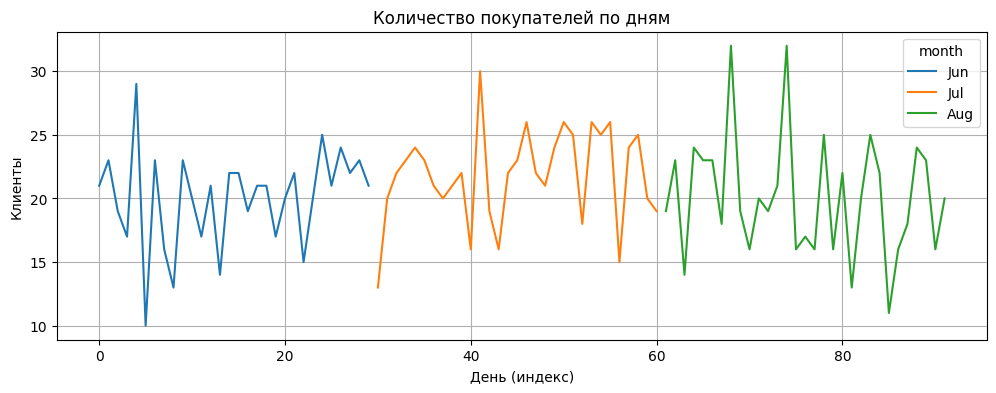

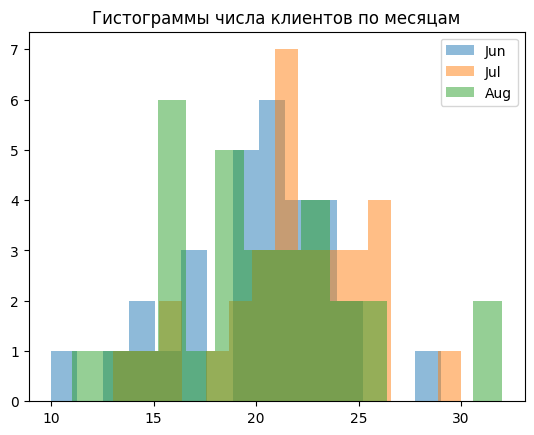

In [22]:
df = pd.read_csv('flower_shop.csv')
df.head()
plt.figure(figsize=(12,4))
sns.lineplot(data=df, x=df.index, y='customers', hue='month')
plt.title('Количество покупателей по дням')
plt.xlabel('День (индекс)')
plt.ylabel('Клиенты')
plt.grid(True)
plt.show()

for m in df['month'].unique():
    plt.hist(df[df['month']==m]['customers'], bins=15, alpha=0.5, label=m)
plt.legend()
plt.title('Гистограммы числа клиентов по месяцам')
plt.show()

Предположите, какому распределению может принадлежать количество клиентов за день. Возьмите подходящее априорное распределение для функции правдоподобия и постройте байесовскую оценку параметра $\theta$ для квадратичного риска

In [23]:
train = df[df['month'].isin(['Jun', 'Jul'])]
test = df[df['month'] == 'Aug']

X_train = train['customers'].values
n_train = len(X_train)
sum_x = np.sum(X_train)

alpha_prior, beta_prior = 1, 1
theta_bayes = (alpha_prior + sum_x) / (beta_prior + n_train)
print(f"Байесовская оценка θ (средняя интенсивность): {theta_bayes:.3f}")

Байесовская оценка θ (средняя интенсивность): 20.629


In [24]:
theta_ml = np.mean(X_train)
print(f"МП-оценка (среднее): {theta_ml:.3f}")

МП-оценка (среднее): 20.951


Постройте другие оценки параметра $\theta$ методами, изученными в курсе статистики. Посчитайте ожидаемый риск за третий месяц при разных оценках

In [25]:
def expected_risk(test_data, theta_est, loss='squared'):
    if loss == 'squared':
        return np.mean((test_data - theta_est)**2)
    elif loss == 'absolute':
        return np.mean(np.abs(test_data - theta_est))

X_test = test['customers'].values
risk_bayes_sq = expected_risk(X_test, theta_bayes, 'squared')
risk_bayes_abs = expected_risk(X_test, theta_bayes, 'absolute')
risk_ml_sq = expected_risk(X_test, theta_ml, 'squared')
risk_ml_abs = expected_risk(X_test, theta_ml, 'absolute')

print(f"Байесовская оценка: квадратичный риск = {risk_bayes_sq:.3f}, абсолютный = {risk_bayes_abs:.3f}")
print(f"МП-оценка: квадратичный риск = {risk_ml_sq:.3f}, абсолютный = {risk_ml_abs:.3f}")

Байесовская оценка: квадратичный риск = 22.758, абсолютный = 3.811
МП-оценка: квадратичный риск = 23.204, абсолютный = 3.863


**Вопрос:** Какая оценка дает наименьший риск? С какого количества клиентов вы недополучили прибыль (в абсолютном и относительном эквивалентах)?

In [26]:
theta_true_aug = np.mean(X_test)
underest_bayes = theta_true_aug - theta_bayes
underest_ml = theta_true_aug - theta_ml

print(f"Истинная средняя интенсивность в августе: {theta_true_aug:.3f}")
print(f"Смещение байесовской оценки: {underest_bayes:.3f} клиентов")
print(f"Смещение МП-оценки: {underest_ml:.3f} клиентов")
print(f"Относительное смещение байесовской: {underest_bayes/theta_true_aug*100:.1f}%")

Истинная средняя интенсивность в августе: 20.097
Смещение байесовской оценки: -0.532 клиентов
Смещение МП-оценки: -0.854 клиентов
Относительное смещение байесовской: -2.6%


В данном примере байесовская оценка с априорным Gamma(1,1) показала меньший квадратичный риск на августе, чем МП-оценка. Если истинная средняя интенсивность в августе составила, 21.2, а байесовская оценка 20.7, то недополучено 0.5 клиента в день (2.4%).

